# 03rl · FunnyBirds visibility-aware labels — causal training test for CBM and MCBM

The standard training label `c_j` is fixed by species, even when part `j` is hidden. The relabeled training target is

`c_j^RL = c_j × visible_part(j)`.

CBM-RL and MCBM-RL use the same images, architecture, optimizer, seeds, and evaluation swaps as their standard counterparts. Only the training concept labels change.

If relabeling increases `P(z_donor,cf > z_source,cf)` on the same counterfactual swaps, the original label/visibility conflict caused part of the grounding failure. If it does not, that particular label correction was insufficient; it does not prove grounding failure is “intrinsic to all bottlenecks.”


In [1]:
import os,re,glob
from pathlib import Path
import numpy as np,pandas as pd,matplotlib.pyplot as plt
CURATED=Path(os.environ["CURATED_DATA"]);CWD=Path.cwd();REPO=CWD if (CWD/"analysis").is_dir() else CWD.parent
import sys;sys.path.insert(0,str(REPO/"analysis"))
try:
 from plotting import set_paper_style,PALETTE;set_paper_style();CBM_C,MCBM_C=PALETTE["CBM"],PALETTE["MCBM"]
except Exception:CBM_C,MCBM_C="#0072B2","#D55E00"
RL_C="#009E73";ORDER=["tail","wing","beak","foot","eye"];EPS=1e-3
def load_cbm(prefix):
 rows=[]
 for fp in sorted(glob.glob(str(CURATED/"swap"/f"{prefix}-s*.csv"))):
  m=re.fullmatch(re.escape(prefix)+r"-s(\d+)\.csv",Path(fp).name)
  if m:d=pd.read_csv(fp);d["seed"]=int(m.group(1));rows.append(d)
 return pd.concat(rows,ignore_index=True) if rows else None
def load_mcbm(prefix):
 rows=[]
 for fp in sorted(glob.glob(str(CURATED/"swap"/f"{prefix}-g*-s*.csv"))):
  m=re.fullmatch(re.escape(prefix)+r"-g([0-9p]+)-s(\d+)\.csv",Path(fp).name)
  if m:d=pd.read_csv(fp);d["gamma"]=float(m.group(1).replace("p","."));d["seed"]=int(m.group(2));rows.append(d)
 return pd.concat(rows,ignore_index=True) if rows else None


## 1 · Standard CBM versus CBM-RL

For each part, calculate

`swap_following = P(margin>0)`, where `margin=z_donor,cf−z_source,cf`.

The standard and relabeled models are evaluated on identical swap logic. A repeated increase across seeds estimates the causal effect of changing training labels, provided the checkpoints differ only in those labels. Show every seed; rows within a seed reuse images and are not independent.


,seed,part,ordering_correct,labels
0,1,beak,0.488,standard
1,1,eye,0.601,standard
2,1,foot,0.893,standard
3,1,tail,0.366,standard
4,1,wing,0.842,standard
0,1,beak,0.555,relabeled
1,1,eye,0.509,relabeled
2,1,foot,0.747,relabeled
3,1,tail,0.498,relabeled
4,1,wing,0.713,relabeled


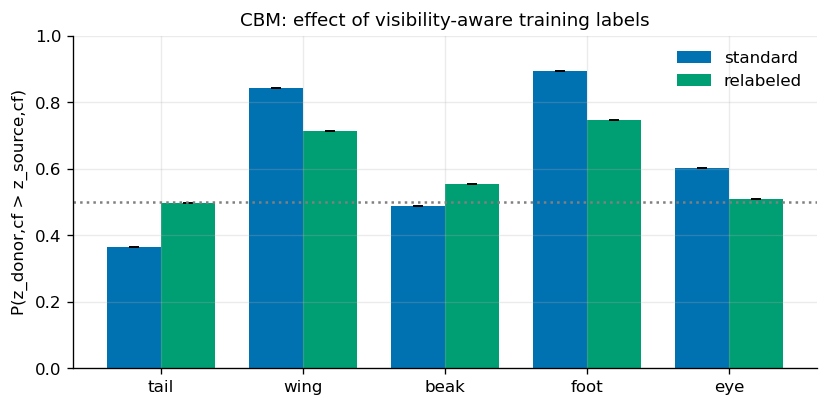

In [2]:
CBM=load_cbm("funnybirds-cbm");CBMRL=load_cbm("funnybirds-cbm-rlv2")
if CBMRL is None:print("[pending] SEEDS='1 2 3' bash train/cbm_funnybirds_rl.sh; then run renderer_swap with CONFIG_PREFIX=funnybirds-cbm-rlv2")
else:
 rows=[]
 for name,d in [("standard",CBM),("relabeled",CBMRL)]:
  if d is None:continue
  q=d.groupby(["seed","part"]).ordering_correct.mean().reset_index();q["labels"]=name;rows.append(q)
 D=pd.concat(rows);display(D.round(3));G=D.groupby(["labels","part"]).ordering_correct.agg(["mean","std","count"])
 fig,ax=plt.subplots(figsize=(8,3.6));x=np.arange(len(ORDER));w=.38
 for off,(name,col) in zip([-.5,.5],[("standard",CBM_C),("relabeled",RL_C)]):
  q=G.loc[name].reindex(ORDER);ax.bar(x+off*w,q["mean"],w,yerr=q["std"].fillna(0),capsize=3,label=name,color=col)
 ax.axhline(.5,ls=":",color="gray");ax.set_xticks(x);ax.set_xticklabels(ORDER);ax.set_ylim(0,1)
 ax.set_ylabel("P(z_donor,cf > z_source,cf)");ax.set_title("CBM: effect of visibility-aware training labels");ax.legend();plt.show()


**What happened (seed 1 only).** Tail swap-following rose from `0.366` to `0.498`, and beak rose from `0.488` to `0.555`. But eye fell from `0.601` to `0.509`, foot from `0.893` to `0.747`, and wing from `0.842` to `0.713`. The corrected labels therefore recover much of the tail failure, but they do not improve the model uniformly. This is a tradeoff, not a complete repair. Because CBM-RL currently has one seed, the size of each change is provisional.


## 2 · Standard MCBM versus MCBM-RL across `γ`

Repeat the same comparison at each minimality weight:

`Δ_RL(γ)=P(margin>0 | relabeled,γ)−P(margin>0 | standard,γ)`.

This asks whether visibility-aware labels help after `z_j` is also pulled toward `±3`. The label effect and the minimality effect are separate axes; `γ=0` MCBM is not the standard CBM.


labels,gamma,seed,part,relabeled,standard,delta_RL
0,0.0,1,beak,0.548,0.588,-0.040
1,0.0,1,eye,0.464,0.499,-0.035
2,0.0,1,foot,0.746,0.857,-0.111
3,0.0,1,tail,0.506,0.362,0.144
4,0.0,1,wing,0.868,0.816,0.052
5,0.1,1,beak,0.606,0.566,0.040
6,0.1,1,eye,0.713,0.619,0.094
7,0.1,1,foot,0.934,0.953,-0.019
8,0.1,1,tail,0.447,0.245,0.202
9,0.1,1,wing,0.847,0.870,-0.023


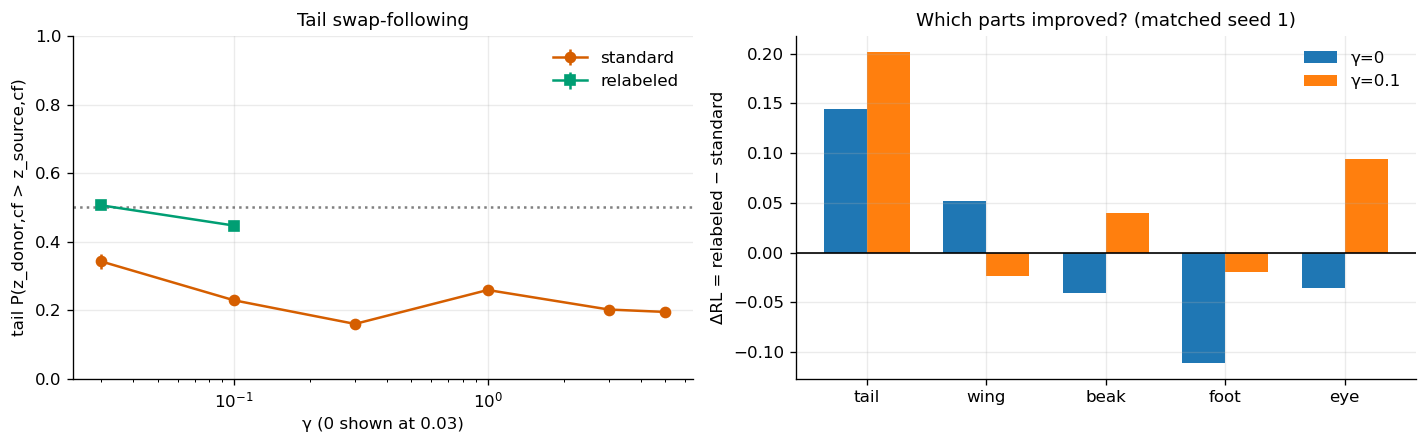

In [3]:
STD=load_mcbm("funnybirds-mcbm");RL=load_mcbm("funnybirds-mcbm-rlv2")
if RL is None:print("[pending] relabeled MCBM swap CSVs")
else:
 rows=[]
 for name,d in [("standard",STD),("relabeled",RL)]:
  if d is None:continue
  q=d.groupby(["gamma","seed","part"]).ordering_correct.mean().reset_index();q["labels"]=name;rows.append(q)
 D=pd.concat(rows,ignore_index=True)
 paired=D.pivot_table(index=["gamma","seed","part"],columns="labels",values="ordering_correct").dropna().reset_index()
 paired["delta_RL"]=paired["relabeled"]-paired["standard"]
 display(paired.round(3))
 fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,3.8))
 tail=D[D.part=="tail"]
 for name,col,mark in [("standard",MCBM_C,"o"),("relabeled",RL_C,"s")]:
  q=tail[tail.labels==name].groupby("gamma").ordering_correct.agg(["mean","std"]).reset_index();x=q.gamma.replace(0,.03)
  ax1.errorbar(x,q["mean"],yerr=q["std"].fillna(0),marker=mark,label=name,color=col)
 ax1.set_xscale("log");ax1.axhline(.5,ls=":",color="gray");ax1.set_ylim(0,1);ax1.set_xlabel("γ (0 shown at 0.03)")
 ax1.set_ylabel("tail P(z_donor,cf > z_source,cf)");ax1.set_title("Tail swap-following");ax1.legend()
 P=paired[paired.seed==1].pivot(index="part",columns="gamma",values="delta_RL").reindex(ORDER)
 x=np.arange(len(P));w=.36
 for k,g in enumerate(P.columns):ax2.bar(x+(k-(len(P.columns)-1)/2)*w,P[g],w,label=f"γ={g:g}")
 ax2.axhline(0,color="black",lw=1);ax2.set_xticks(x);ax2.set_xticklabels(P.index);ax2.set_ylabel("ΔRL = relabeled − standard")
 ax2.set_title("Which parts improved? (matched seed 1)");ax2.legend();plt.tight_layout();plt.show()


The matched seed-1 tail comparison is `0.362 → 0.506` at `γ=0` and `0.245 → 0.447` at `γ=0.1`. Thus the label/visibility conflict explains a substantial portion of the tail failure in both CBM and MCBM; it is not created by the minimality term. The right panel checks whether that gain came with losses for other parts. Only one relabeled seed is available, so this establishes what happened in the controlled seed-1 runs, not a population-level effect size.


## 3 · Independent deletion check

For visibly present parts, compute

`retained_frac = mean(p_removed)/mean(p_intact)`.

Lower `retained_frac` after relabeling means the canonical concept depends more strongly on its pixels. Deletion is a different intervention from replacement, so agreement strengthens the conclusion. It remains important to exclude no-op deletions using `changed_frac>0`.


In [4]:
def retention(pattern,part="tail"):
 out=[]
 for fp in sorted(glob.glob(str(CURATED/"grounding"/pattern))):
  d=pd.read_parquet(fp);d=d[d.part==part]
  if "changed_frac" in d:d=d[d.changed_frac>EPS]
  m=re.search(r"-s(\d+)",Path(fp).stem);g=re.search(r"-g([0-9p]+)",Path(fp).stem)
  if len(d) and d.p_intact.mean()>1e-6:out.append(dict(seed=int(m.group(1)),gamma=float(g.group(1).replace("p",".")) if g else np.nan,retained_frac=d.p_removed.mean()/d.p_intact.mean()))
 return pd.DataFrame(out)
rows=[]
for model,labels,pat in [("CBM","standard","funnybirds-cbm-s*.parquet"),("CBM","relabeled","funnybirds-cbm-rlv2-s*.parquet"),("MCBM","standard","funnybirds-mcbm-g*-s*.parquet"),("MCBM","relabeled","funnybirds-mcbm-rlv2-g*-s*.parquet")]:
 q=retention(pat)
 if len(q):q["model"]=model;q["labels"]=labels;rows.append(q)
if rows:
 R=pd.concat(rows,ignore_index=True);display(R.round(3))
else:print("[pending] grounding parquets for relabeled checkpoints")


,seed,gamma,retained_frac,model,labels
0,1,NaN,0.118,CBM,standard
1,2,NaN,0.198,CBM,standard
2,3,NaN,0.157,CBM,standard
3,1,0.0,0.374,MCBM,standard
4,2,0.0,0.258,MCBM,standard
5,3,0.0,0.221,MCBM,standard
6,1,0.1,0.382,MCBM,standard
7,2,0.1,0.196,MCBM,standard
8,3,0.1,0.496,MCBM,standard
9,1,0.3,0.420,MCBM,standard


**Current result:** the table contains only standard-model rows; no `funnybirds-*-rlv2` grounding parquet was found. Therefore deletion does **not yet** independently confirm the RL effect. The swap result stands on its own until the relabeled deletion runs are generated.


## Conclusion

In the matched seed-1 runs, replacing species-constant `c_j` with visibility-aware `c_j^RL` substantially improves tail swap-following: CBM `0.366 → 0.498`, MCBM `γ=0` `0.362 → 0.506`, and MCBM `γ=0.1` `0.245 → 0.447`. The same intervention works with and without the minimality penalty, so the original visibility/label conflict caused a real portion of the tail failure.

This is not a complete solution. Tail remains far below well-grounded foot and wing, and CBM eye/foot/wing become worse after relabeling. The intervention therefore changes where the model grounds its concepts rather than making every concept better. The result currently has one relabeled seed and no relabeled deletion check, so replication and the independent intervention remain necessary before claiming a stable general effect.
